# 05_01 Dropout Sweep

Primary sweep for the dropout-aware policy claim: as sensitive-item dropout pressure increases, does the weighted surrogate preserve information while reducing abandonment?

Use the selection cell once. Leave `SWEEP_FILE = None` to load the latest matching dropout sweep, or paste an exact JSON filename from `show_sweeps()` for reproducible figure work.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "_sweep_helpers.py").exists():
    sys.path.append(str(NOTEBOOK_DIR))
elif (NOTEBOOK_DIR / "notebooks" / "_sweep_helpers.py").exists():
    sys.path.append(str(NOTEBOOK_DIR / "notebooks"))
else:
    sys.path.append(str(Path(r"C:/Users/49160/Adaptive-Onboarding/notebooks")))

from _sweep_helpers import (
    POLICY_STYLE,
    config_label,
    equalize_y_axes,
    load_run,
    load_sweep,
    plot_metric_lines,
    plot_pareto,
    plot_weighted_delta,
    save,
    setup,
    show_sweeps,
    style_ax,
)

setup()

Results directory: C:\Users\49160\Adaptive-Onboarding\experiments\results


## Select Sweep

In [12]:
PARAM = "dropout"
SWEEP_FILE = None  # e.g. "20260428_164550_sweep_dropout.json"
CONFIG_FILTER = {"dim":6}  # e.g. {"dim": 2, "horizon": 12, "n_users": 500}

show_sweeps(PARAM)
sweep = load_sweep(PARAM, sweep_file=SWEEP_FILE, config_filter=CONFIG_FILTER)
print(config_label(sweep))

 0: 20260429_101757_sweep_dropout.json  (dim=2, h=12, n=500, items=30, s_frac=0.3, sens=high_trait_tail, axes=[1], p_drop=varied)
 1: 20260428_164550_sweep_dropout.json  (dim=6, h=20, n=500, items=50, s_frac=0.3, sens=random, p_drop=varied)
Loading latest matching file: 20260428_164550_sweep_dropout.json
dim=6, h=20, n=500, items=50, s_frac=0.3, sens=random, p_drop=varied


## Dropout Pressure

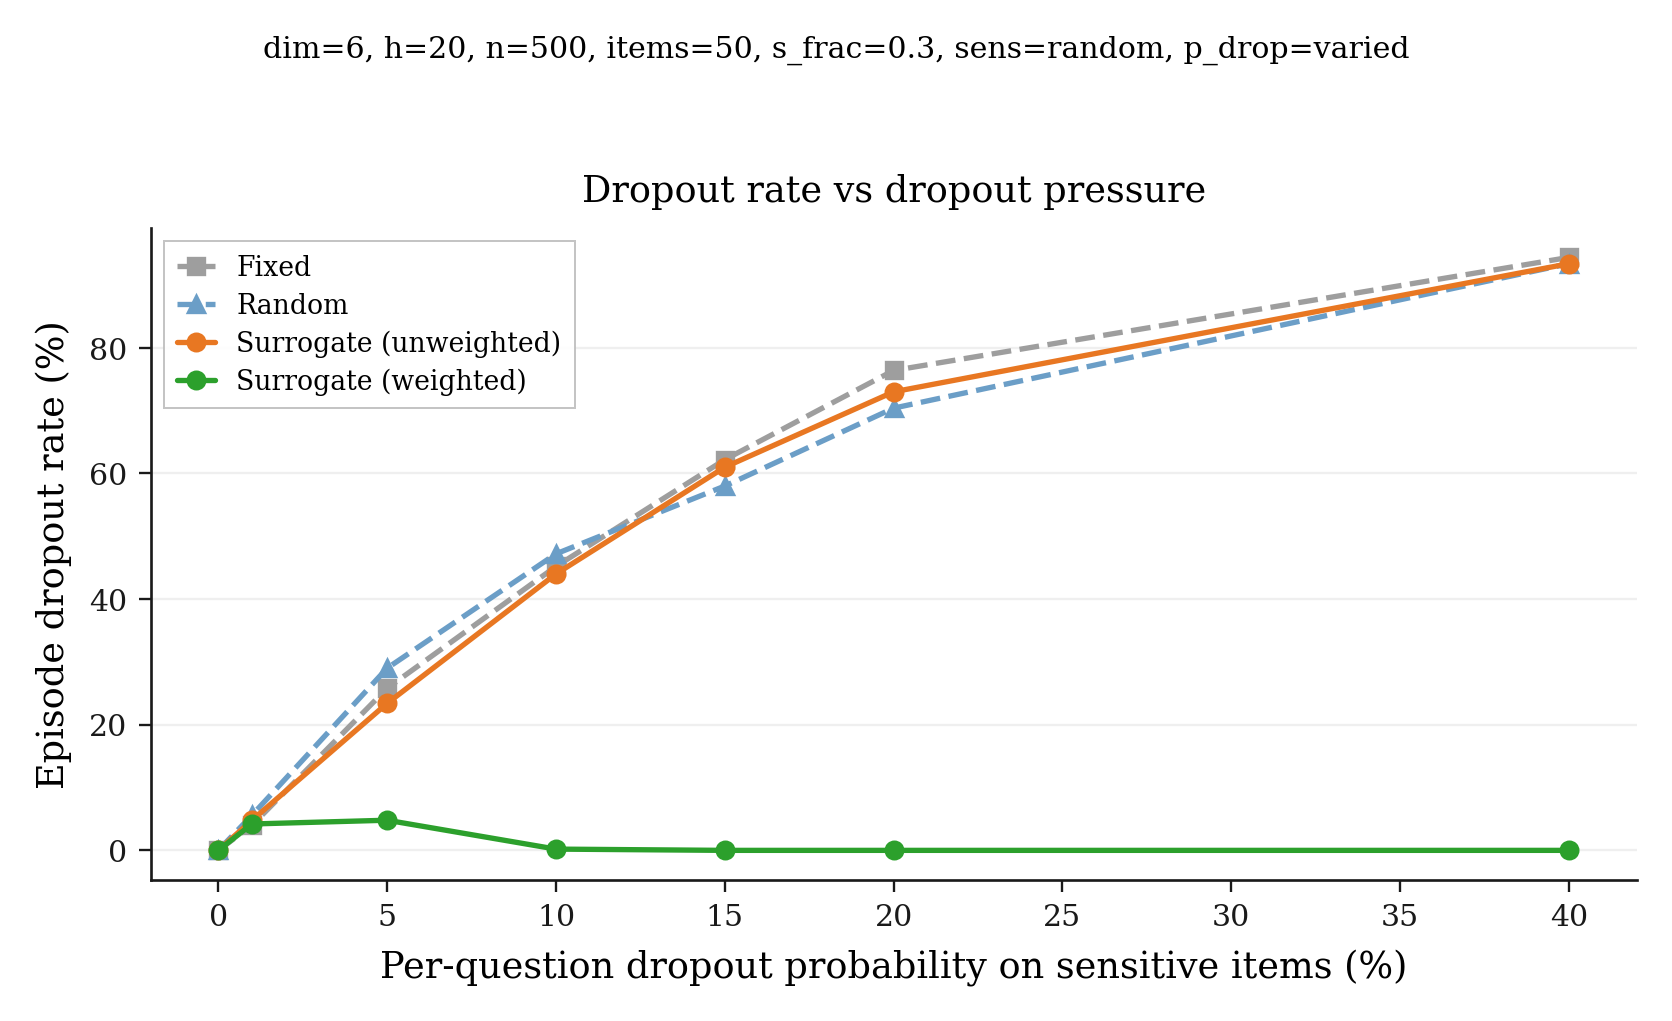

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_metric_lines(
    ax, sweep, "dropout_rate",
    x_scale=100, y_scale=100,
    xlabel="Per-question dropout probability on sensitive items (%)",
    ylabel="Episode dropout rate (%)",
    title="Dropout rate vs dropout pressure",
)
fig.suptitle(config_label(sweep), y=1.03, fontsize=9)
plt.tight_layout()
# save(fig, "fig_05_01_dropout_rate_vs_pressure")
plt.show()

## Information Quality: All vs Completed

The completed-only panel is conditional on users finishing the questionnaire. It reduces dropout truncation, but it is still a selected subset, so interpret it alongside dropout rate.

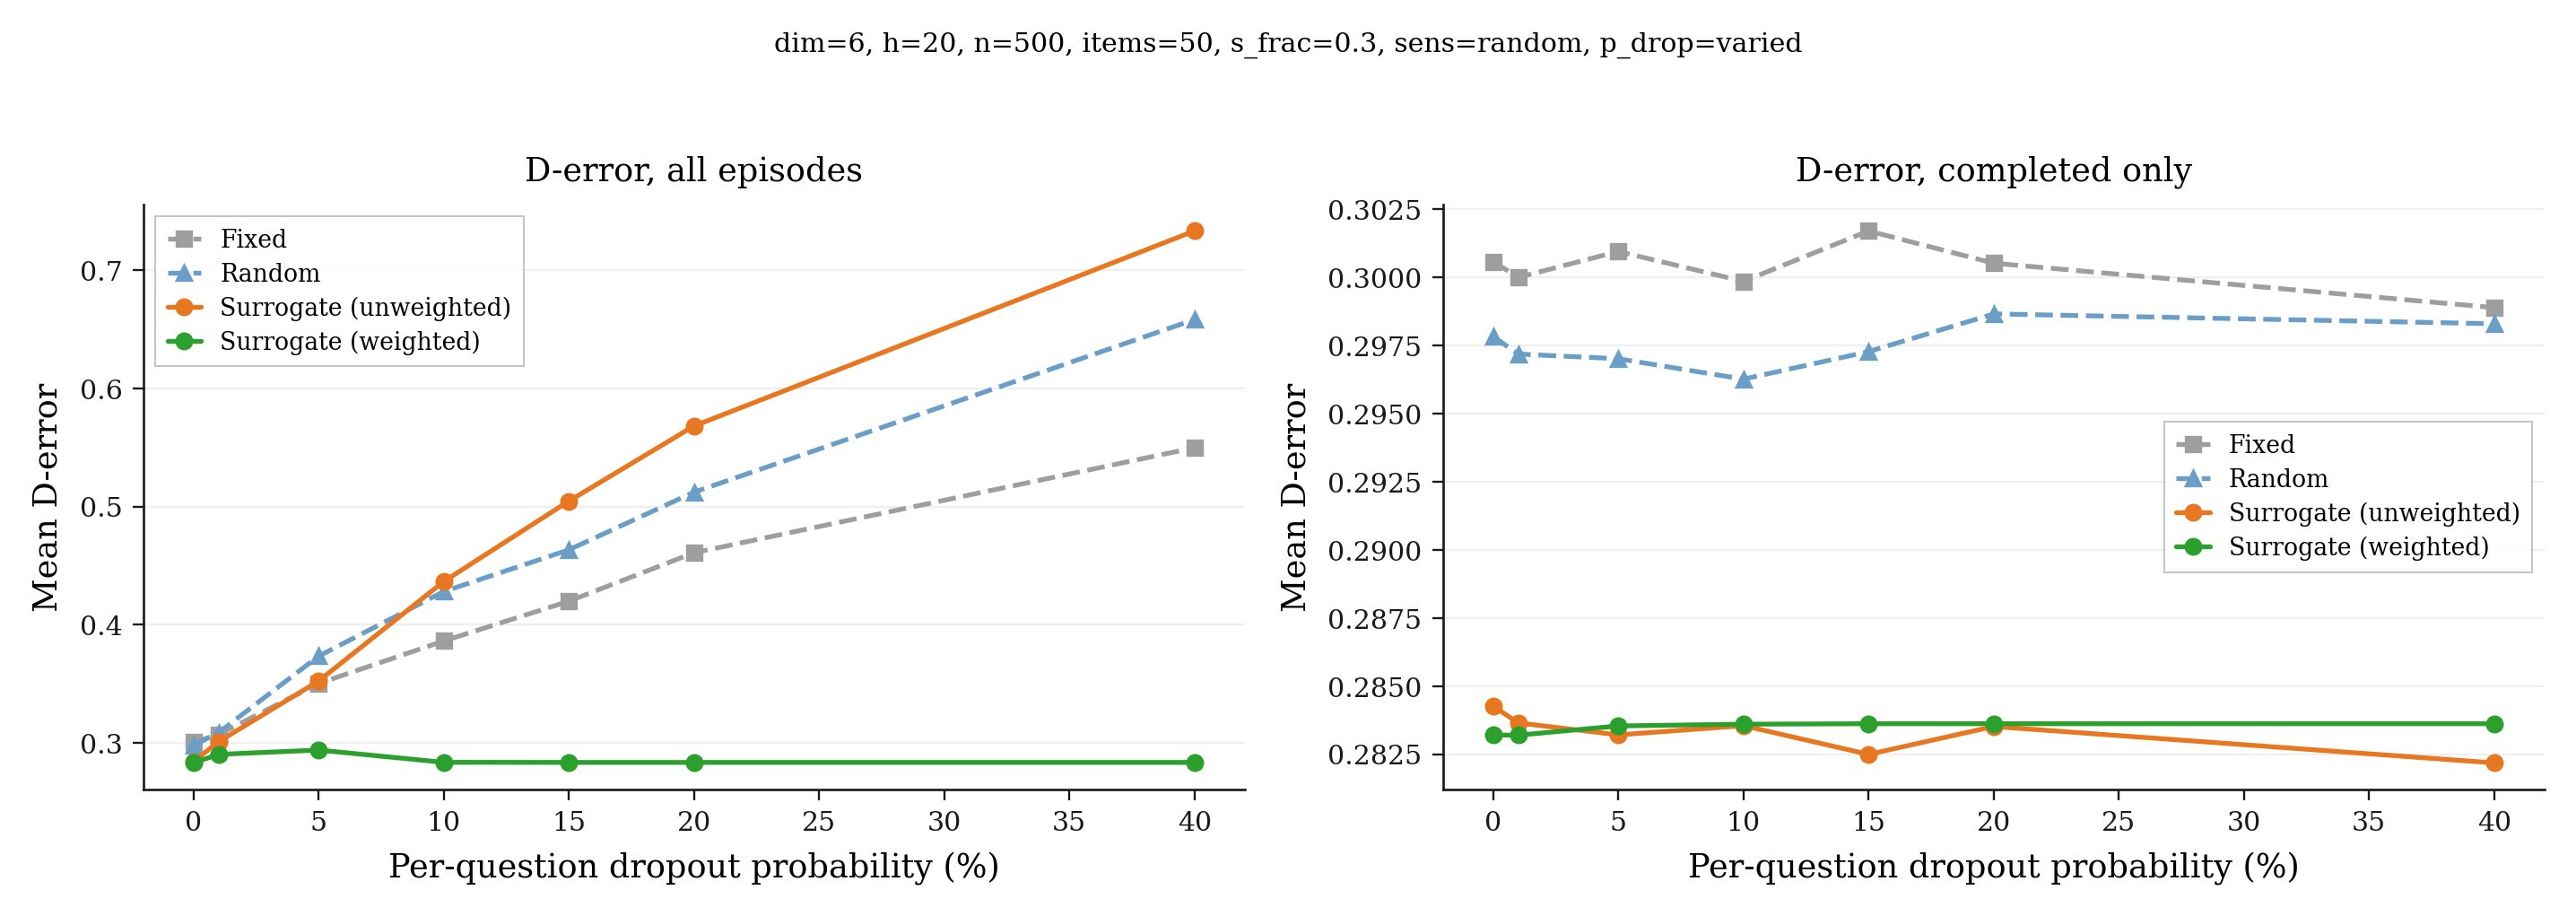

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_metric_lines(
    axes[0], sweep, "mean_final_d_error",
    x_scale=100,
    xlabel="Per-question dropout probability (%)",
    ylabel="Mean D-error",
    title="D-error, all episodes",
)
plot_metric_lines(
    axes[1], sweep, "mean_final_d_error_completed",
    x_scale=100,
    xlabel="Per-question dropout probability (%)",
    ylabel="Mean D-error",
    title="D-error, completed only",
)
fig.suptitle(config_label(sweep), y=1.03, fontsize=9)
plt.tight_layout()
# save(fig, "fig_05_01_d_error_vs_dropout")
plt.show()

## Exposure and Truncation

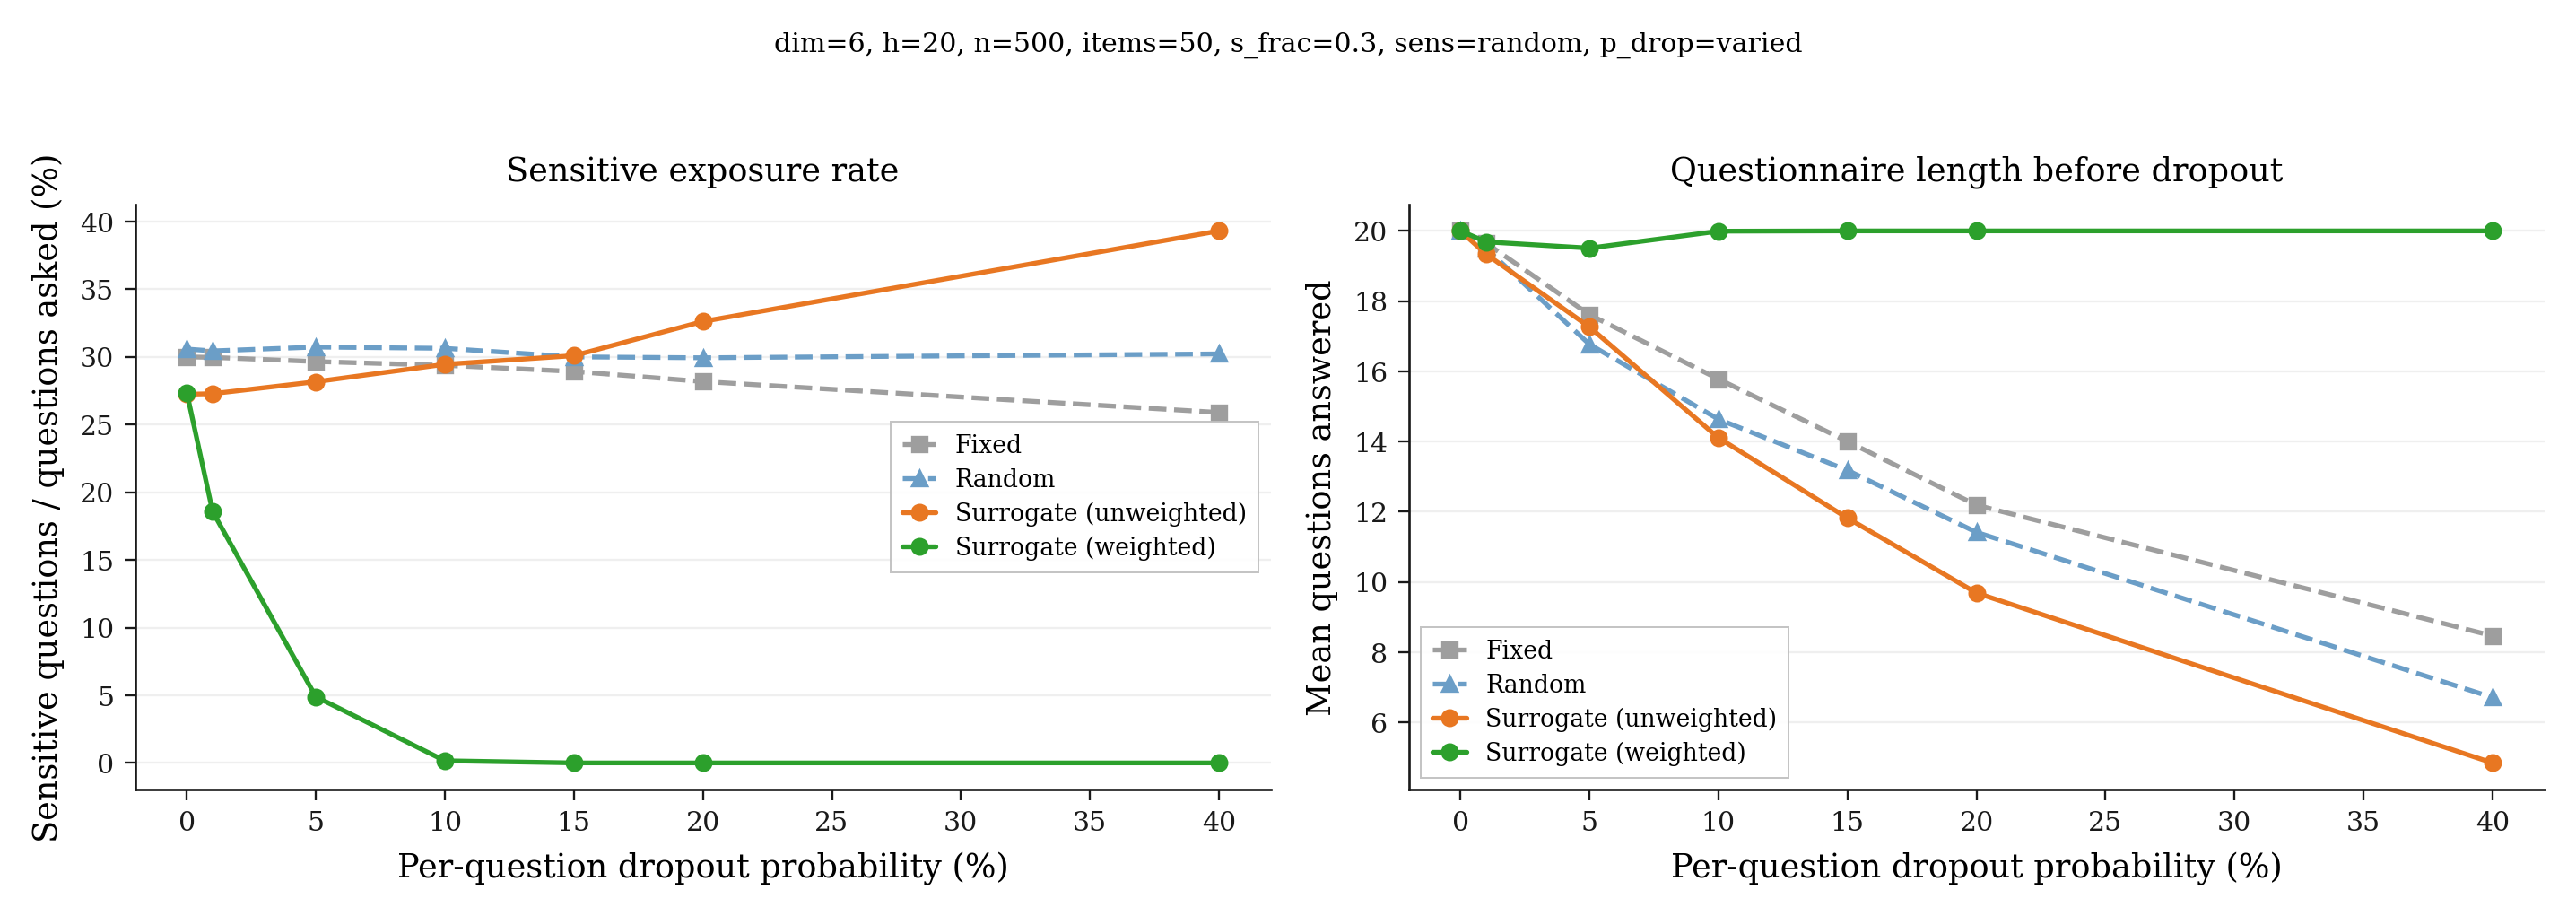

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_metric_lines(
    axes[0], sweep, "sensitive_rate",
    x_scale=100, y_scale=100,
    xlabel="Per-question dropout probability (%)",
    ylabel="Sensitive questions / questions asked (%)",
    title="Sensitive exposure rate",
)
plot_metric_lines(
    axes[1], sweep, "mean_n_answered",
    x_scale=100,
    xlabel="Per-question dropout probability (%)",
    ylabel="Mean questions answered",
    title="Questionnaire length before dropout",
)
fig.suptitle(config_label(sweep), y=1.03, fontsize=9)
plt.tight_layout()
# save(fig, "fig_05_01_exposure_and_truncation")
plt.show()

## Dropout-Risk vs Error

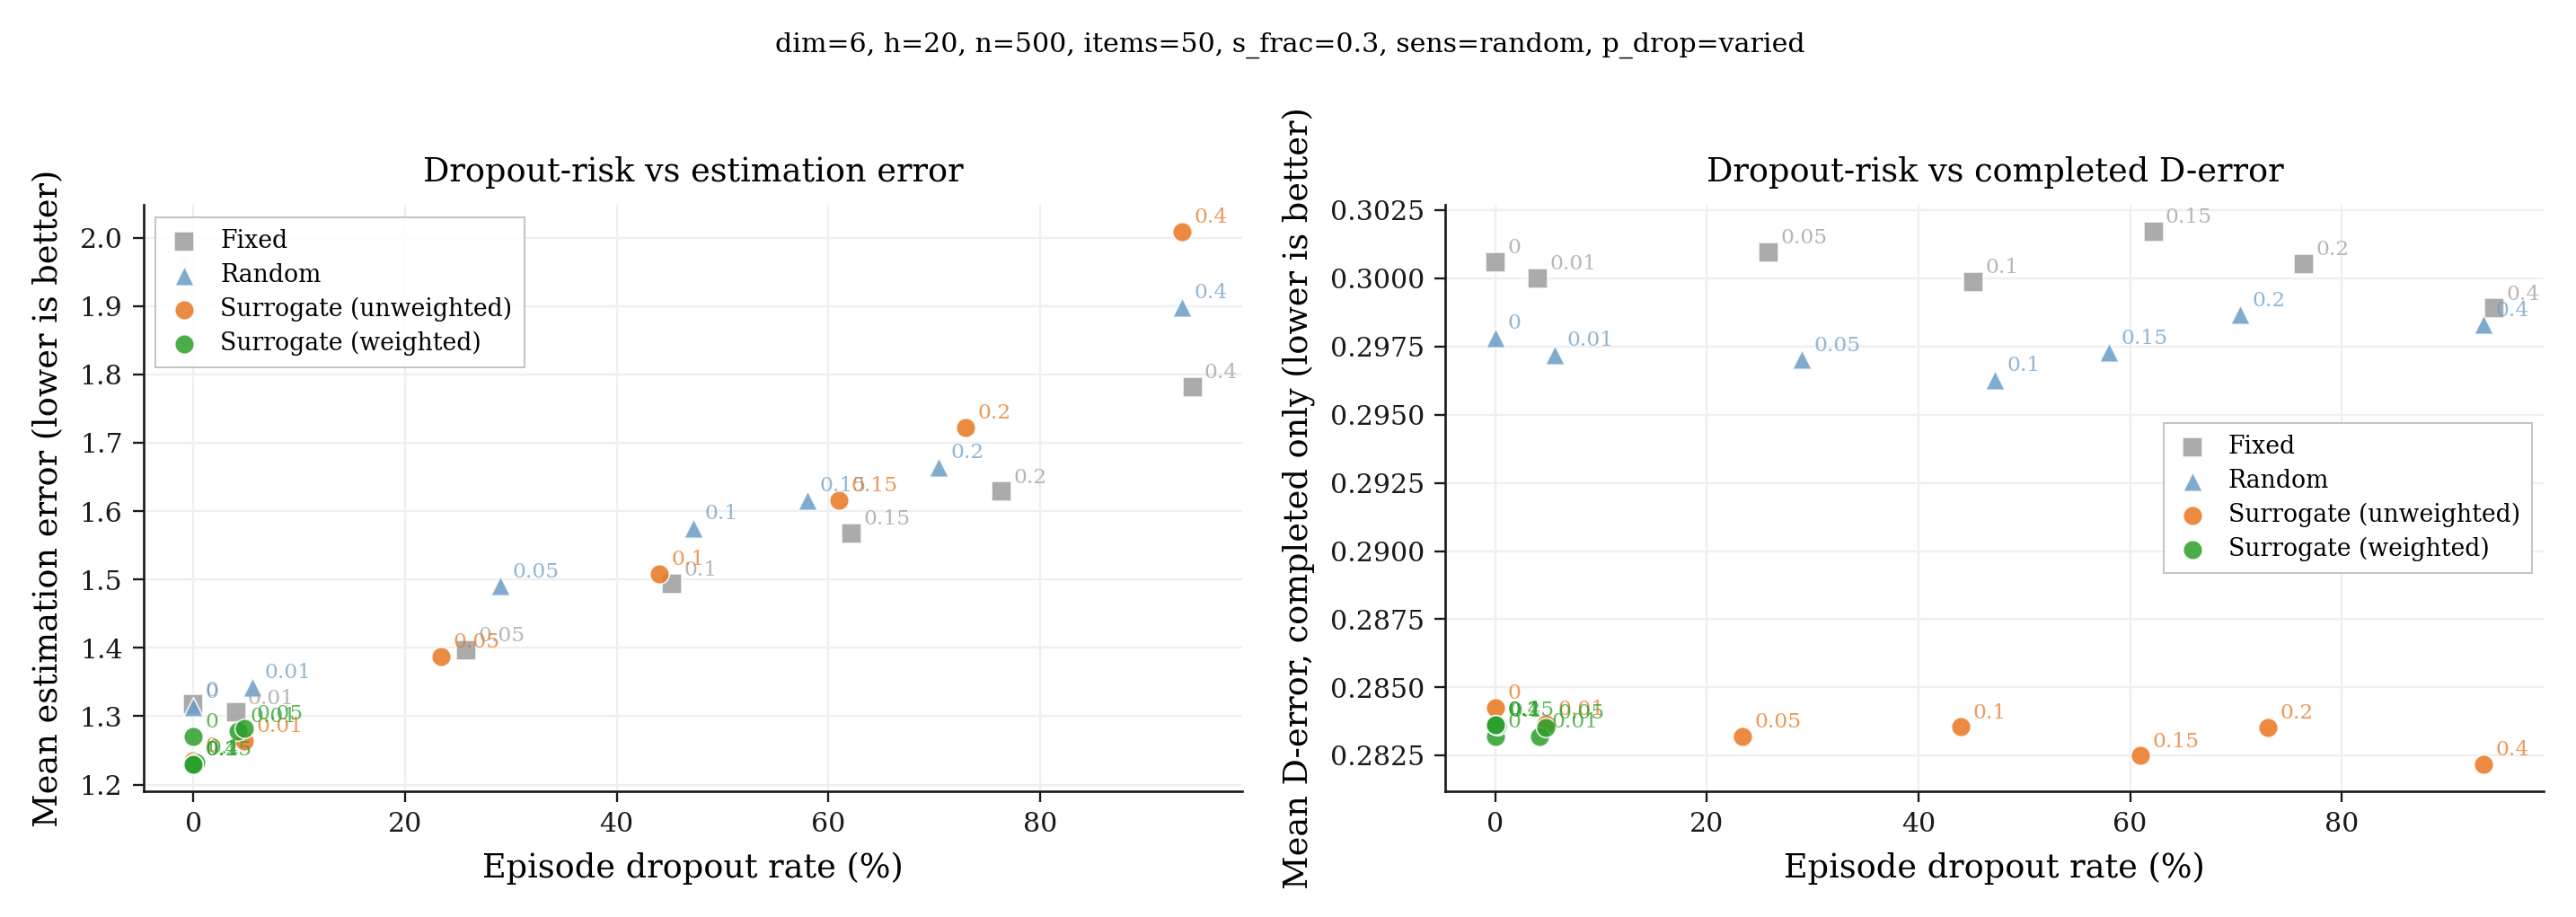

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pareto(
    axes[0], sweep,
    y_metric="mean_estimation_error",
    ylabel="Mean estimation error (lower is better)",
    title="Dropout-risk vs estimation error",
)
plot_pareto(
    axes[1], sweep,
    y_metric="mean_final_d_error_completed",
    ylabel="Mean D-error, completed only (lower is better)",
    title="Dropout-risk vs completed D-error",
)
fig.suptitle(config_label(sweep), y=1.03, fontsize=9)
plt.tight_layout()
# save(fig, "fig_05_01_pareto")
plt.show()

## Weighted Minus Unweighted

Negative dropout-rate delta means the weighted surrogate reduces dropout relative to the unweighted surrogate. Negative error delta means it also improves the corresponding error metric.

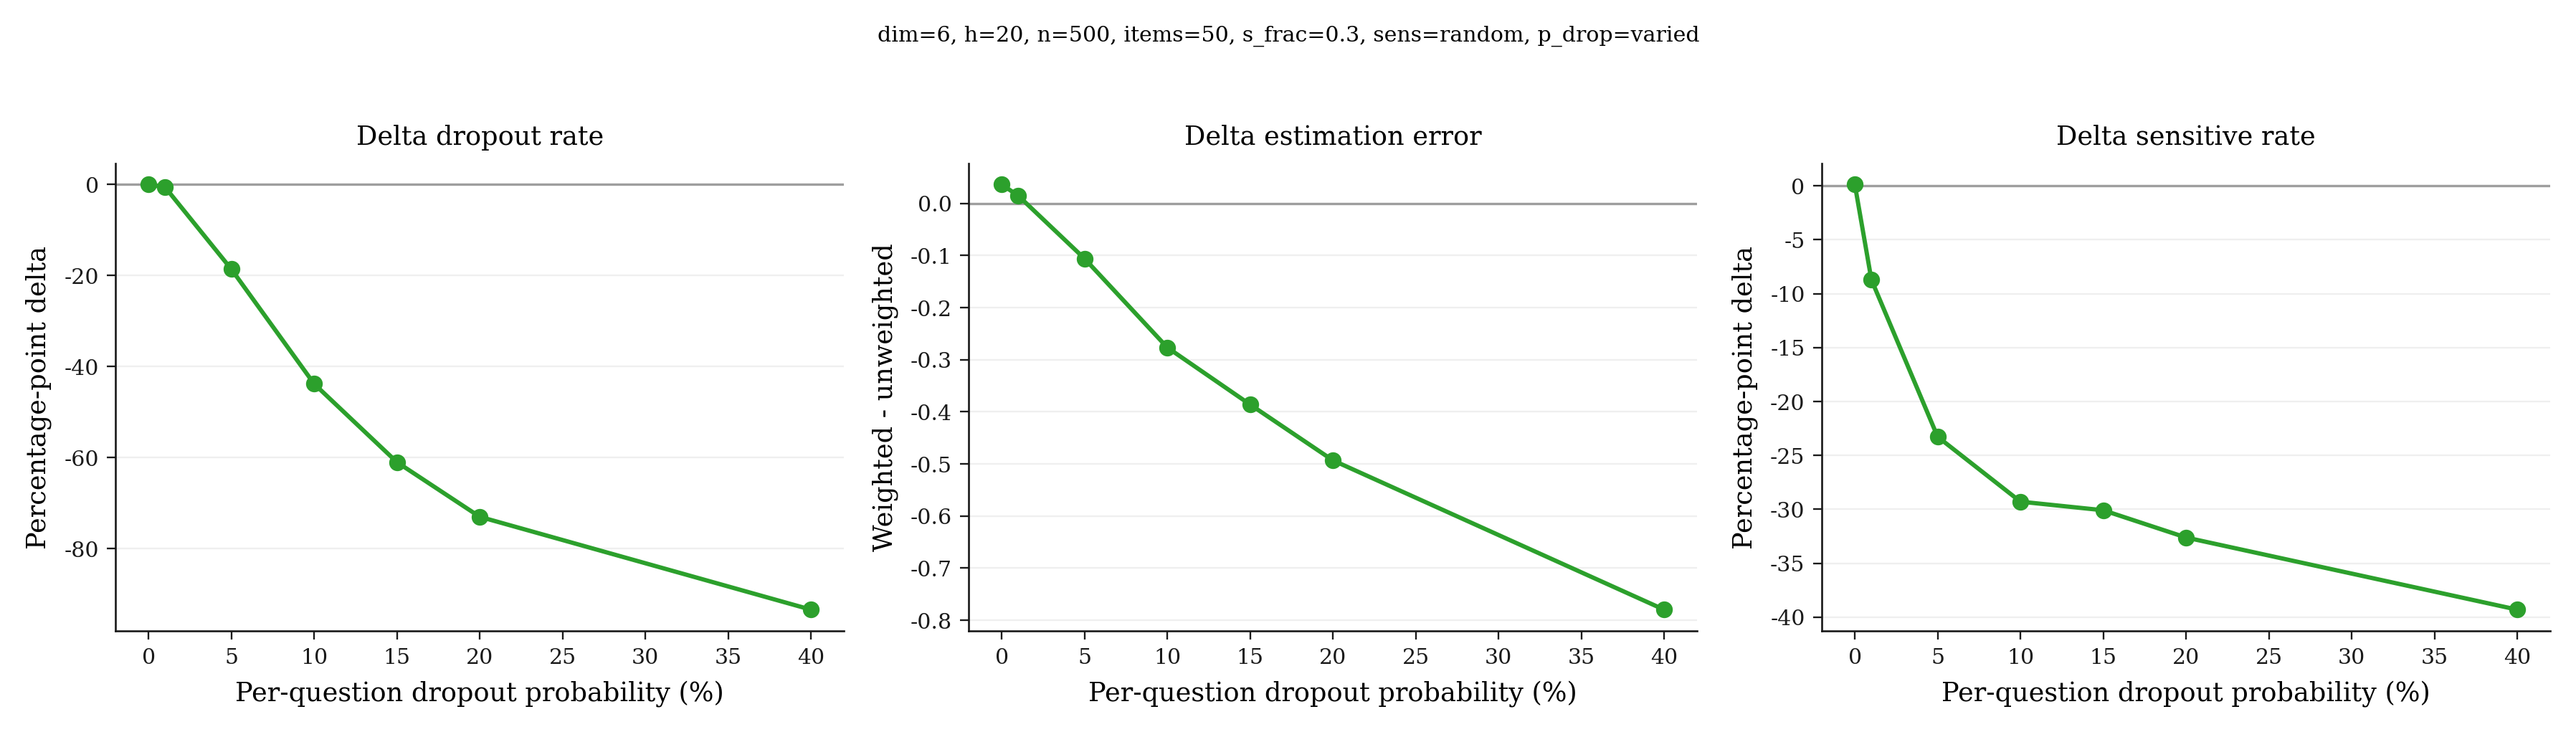

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_weighted_delta(
    axes[0], sweep, "dropout_rate",
    x_scale=100, y_scale=100,
    xlabel="Per-question dropout probability (%)",
    ylabel="Percentage-point delta",
    title="Delta dropout rate",
)
plot_weighted_delta(
    axes[1], sweep, "mean_estimation_error",
    x_scale=100,
    xlabel="Per-question dropout probability (%)",
    ylabel="Weighted - unweighted",
    title="Delta estimation error",
)
plot_weighted_delta(
    axes[2], sweep, "sensitive_rate",
    x_scale=100, y_scale=100,
    xlabel="Per-question dropout probability (%)",
    ylabel="Percentage-point delta",
    title="Delta sensitive rate",
)
fig.suptitle(config_label(sweep), y=1.03, fontsize=9)
plt.tight_layout()
# save(fig, "fig_05_01_weighted_minus_unweighted")
plt.show()

Computes surrogate_weighted metric - surrogate_unweighted metric at every step, visualizes gains in dropout through the weighting mechanism.